# Define paths

In [1]:
import os
import numpy as np
# Define the present path as root path
root_path = os.getcwd()
print(root_path)

/Users/martino/Nextcloud/CNRS/work/programs/nested_fit/nested_fit/benchmarks_and_tests


# Installation (if needed)

## Remote pip installation from release

In [2]:
## Install stable version
#!pipx install nested_fit

## Install development version
#!pipx install -pre nested_fit

## Local installation

In [3]:
## Clone the repository
#!git clone https://github.com/martinit18/nested_fit.git

## Prepare cmake build. Eventually change $HOME to the desired installation path
#!cd nested_fit
#!mkdir -p build
#!cmake -S . -B build  -DOPENMP=ON -DCMAKE_BUILD_TYPE=Release -DCMAKE_INSTALL_PREFIX=$HOME

## Build and install the package
#!cmake --build build --target install

## Eventually export the path to the executables
#!export PATH=$HOME/bin:$PATH

## Install locally with pip
#!pip install -e . -v

# Import libraries

In [4]:
#from matplotlib.pyplot import * 
#from numpy import *
import pynested_fit as pynf

%matplotlib inline
#%matplotlib widget
#%matplotlib notebook

In [5]:
pynf.__version__

'5.6.8'

# Benchkmarks and tests

In [6]:
# Define a function to check compatibility of two values with given tolerances
def is_compatible(a, b, rtol=1e-3, atol=1e-6,show=True):
    from IPython.display import display, Markdown
    compatible = np.allclose(out['evidence']['value'], evidence_ref, atol=max(evidence_ref_error, out['evidence']['uncertainty']))
    display(Markdown(
    "<span style='font-size:24px; color:green'>🟢 Compatible</span>"
    if compatible else
    "<span style='font-size:24px; color:red'>🔴 Not compatible</span>"
    ))
    return compatible

## Single Gaussian with background with real data

### Define reference values

In [44]:
# Evidence
evidence_ref =  -574.5
evidence_ref_error = 5*0.20

# Parameter values
par1_ref = 454.6     # Value of x0 
par1_ref_error = 1.7

### Choose the number of live points

In [49]:
K = 10000

### Run the code

In [50]:
# Go to a define analysis
path = root_path+'/test_01_gauss_bg'
os.chdir(path)

In [51]:
#### Define inputs using a "latex" function
conf = pynf.Configurator(
    datafiles=['he-histo.dat'], # Name of the data file
    filefmt='.tsv',             # Format of file (here for tab and space separated)
    specstr='x,c',              # Datafile layout (here ch. and counts in ch.)
    expressions=[               # Function expression in latex form
        r'gauss_bg(x, A_1, x_1, s, b_g) = \texttt{GAUSS_IF}(x, x_1, A_1, s) + b_g'], 
    params={                    # function expression in latex form
        'b_g': {'value': 0.01,  'step': -1, 'min': 0,   'max': 0.3 },
        'x_1': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'A_1': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        's':   {'value': 20,    'step': -1, 'min': 10,  'max': 30}
    },
    data={'xmin': 1, 'xmax': 1024},  # Boundaries of data
    livepoints=K,                  # Number of live points
    search_method='SLICE_SAMPLING',   # Search method
    search_params=(0.5, 3),           # Parameters of chosen method
    search_maxsteps=100000,           # Max steps of nested sampling
    conv_accuracy=1.E-05,             # Evidence final accuracy
    cluster_enable=False,             # clustering recognition on/off
    # cluster_method='k',             # method used
    # cluster_parameter1=0.5,         # method parameter 1 (if needed)
    # cluster_parameter2=0.2,         # method parameter 1 (if needed)
)

In [52]:
# Run the code

# For visualising the progress of the execution use this command
#out = conf.sample(output_mode='live')

# For visualising the progress graphycally (not working in Google Colab), use
# out = conf.sample(output_mode='full')

# If nothing shows, use simply the command (symlink to created or version to be used)
# Create the command to run nested fit in case of need
# run_nested_fit = os.system('nested_fit'+pynf.__version__)
# run_nested_fit

# For silently running the code and save the raw output in a dictionnary, use this command
out = conf.sample(output_mode='none')

### Visualize the results

In [53]:
# Load the nested output data
# The available parameters and other variables that can be plotted are listed
an=pynf.Analysis()

Current path =  .
Result file nf_output_energy.txt not present
 No energies data loaded
['A_1', 'x_1', 's', 'b_g']
Index(['weight', 'lnlikelihood', 'A_1', 'x_1', 's', 'b_g'], dtype='str')
Available parameters : ['weight', 'lnlikelihood', 'A_1', 'x_1', 's', 'b_g']


0 max
nf_output_data_max.dat


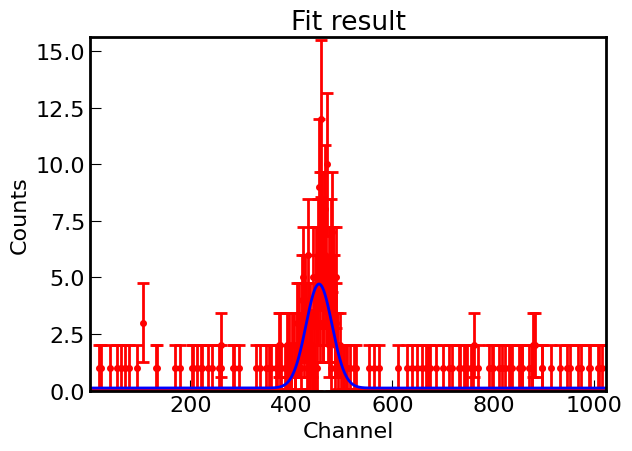

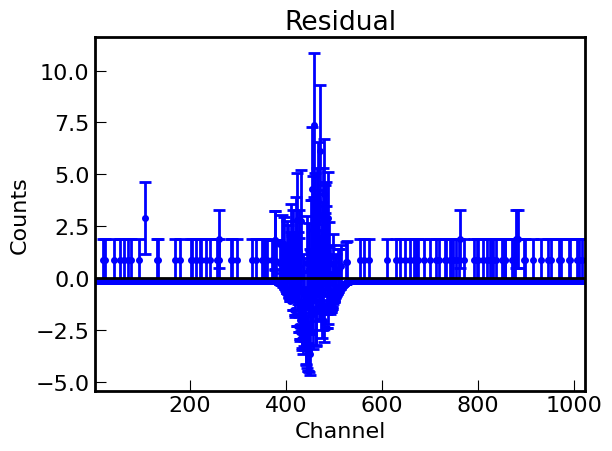

In [54]:
# Plot the data with the best fit (parameters corresponding to the maximum value of the data) and residual
# Other choices are median and mean parameters values selectable with "typeof='mean'" and "typeof='median'"
an.plot()

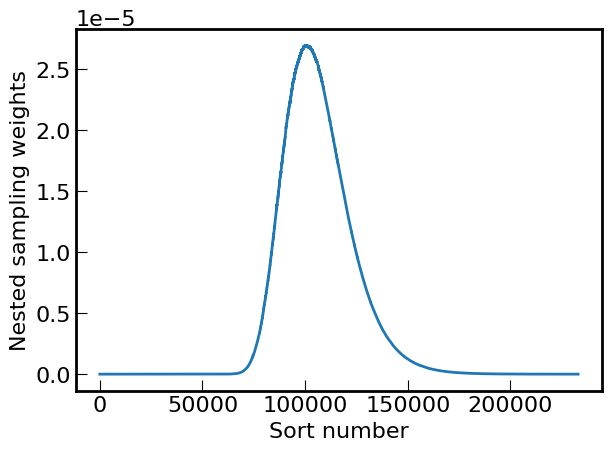

In [55]:
# Plot the weights of nested sampling corresponding to w_n = Delta X_n L_n
an.plot_weights()

### Check values

In [56]:
# Extract the raw information of evidence
print(f" Evidence: {out['evidence']['value']:.3f} ±{out['evidence']['uncertainty']:.3f}")


# Check values
is_compatible(out['evidence']['value'], evidence_ref, atol=max(evidence_ref_error, out['evidence']['uncertainty']))


 Evidence: -574.842 ±0.030


<span style='font-size:24px; color:green'>🟢 Compatible</span>

True

In [57]:
# Specific information of output parameters
par_name = 'x_1'
print(par_name, ' = ', out['params'][par_name][ 'mean'],' ± ', out['params'][par_name][ 'std'])

# Check values
is_compatible(out['params'][par_name][ 'mean'], par1_ref, atol=max(par1_ref_error, out['params'][par_name][ 'std']))

x_1  =  454.6283287250583  ±  1.7052801658447574


<span style='font-size:24px; color:green'>🟢 Compatible</span>

True

### Extract computation time

In [58]:
# Miscelaneous information
out['meta']['timereal']

52.72080199999618

## Four Gaussian plus background

### Define reference values

In [59]:
# Evidence
evidence_ref =  -326.1
evidence_ref_error = 5*0.10

# Parameter values
par1_ref = 14.7    # Value of s 
par1_ref_error = 1.3

### Choose the number of live points

In [60]:
K = 10000

### Run the code

In [61]:
# Go to a define analysis
path = root_path+'/test_03_4gauss_bg'
os.chdir(path)

In [62]:
# Define inputs using a "latex" function
conf = pynf.Configurator(
    datafiles=['he-histo.dat'], # Name of the data file
    filefmt='.tsv',             # Format of file (here for tab and space separated)
    specstr='x,c',              # Datafile layout (here ch. and counts in ch.)
    expressions=[               # Function expression in latex form using an internal function (twice)
        r'four_gauss_bg(x, x_1, x_2, x_3, x_4, A_1, A_2, A_3, A_4, s, b_g) =' + 
        r' + \texttt{GAUSS_IF}(x, x_1, A_1, s)' +  # These additional "+" are to write in more than one line
        r' + \texttt{GAUSS_IF}(x, x_2, A_2, s)' + 
        r' + \texttt{GAUSS_IF}(x, x_3, A_3, s)' + 
        r' + \texttt{GAUSS_IF}(x, x_4, A_4, s) + b_g'], 
    params={                    # function expression in latex form
        'b_g': {'value': 0.01,  'step': -1, 'min': 0,   'max': 0.3 },
        'x_1': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'x_2': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'x_3': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'x_4': {'value': 454.6, 'step': -1, 'min': 300, 'max': 600 },
        'A_1': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        'A_2': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        'A_3': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        'A_4': {'value': 300,   'step': -1, 'min': 0,   'max': 500},
        's':   {'value': 20,    'step': -1, 'min': 10,  'max': 30}
    },
    data={'xmin': 250, 'xmax': 650},  # Boundaries of data
    livepoints=K,                  # Number of live points
    search_method='SLICE_SAMPLING',   # Search method
    search_params=(0.5, 3),           # Parameters of chosen method
    search_maxsteps=100000,           # Max steps of nested sampling
    conv_accuracy=1.E-05,             # Evidence final accuracy
    # num_tries=4,                    # Number of run of the same analysis for error estimation
    cluster_enable=True,              # clustering recognition on/off
    # cluster_method='k',             # method used
    # cluster_parameter1=0.5,         # method parameter 1 (if needed)
    # cluster_parameter2=0.2,         # method parameter 1 (if needed)
)

In [63]:
# Run the code

out = conf.sample(output_mode='none')

### Visualize the results 

In [64]:
# Load the nested output data
# The available parameters and other variables that can be plotted are listed
an=pynf.Analysis()

Current path =  .
Result file nf_output_energy.txt not present
 No energies data loaded
['x_1', 'x_2', 'x_3', 'x_4', 'A_1', 'A_2', 'A_3', 'A_4', 's', 'b_g']
Index(['weight', 'lnlikelihood', 'x_1', 'x_2', 'x_3', 'x_4', 'A_1', 'A_2',
       'A_3', 'A_4', 's', 'b_g'],
      dtype='str')
Available parameters : ['weight', 'lnlikelihood', 'x_1', 'x_2', 'x_3', 'x_4', 'A_1', 'A_2', 'A_3', 'A_4', 's', 'b_g']


0 max
nf_output_data_max.dat


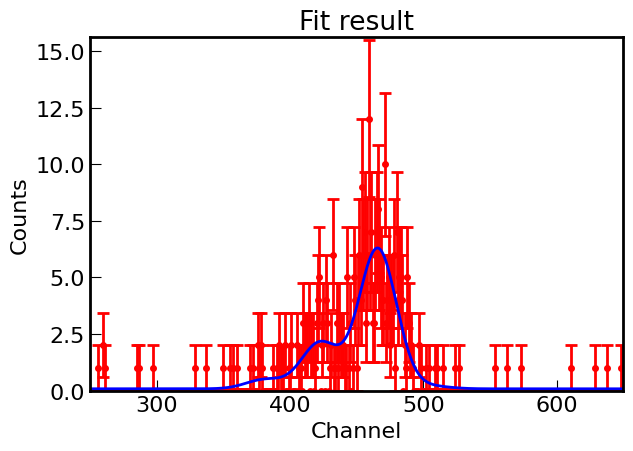

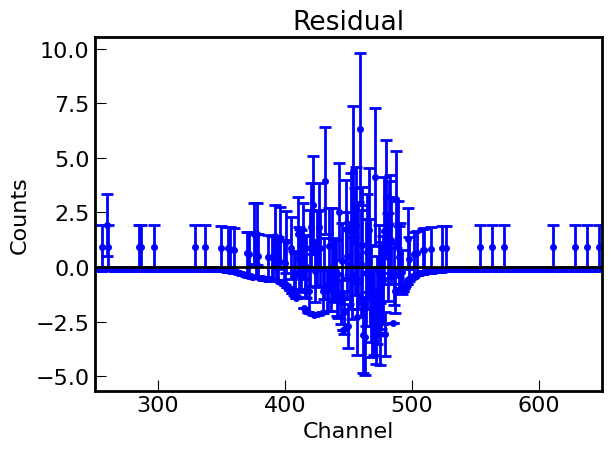

In [65]:
# Plot the data with the best fit (parameters corresponding to the maximum value of the data) and residual
# Other choices are median and mean parameters values selectable with "typeof='mean'" and "typeof='median'"
an.plot()

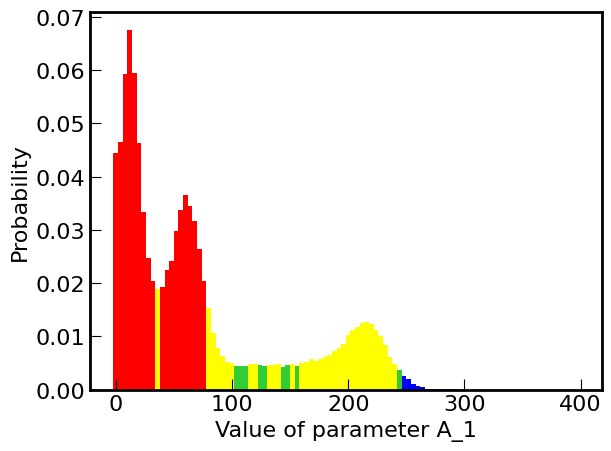

In [66]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo('A_1',bins=100,xmin=0,xmax=400)

/Users/martino/Nextcloud/CNRS/work/programs/nested_fit/nested_fit/pynested_fit/nested_res.py:1178: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data68[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb68)
/Users/martino/Nextcloud/CNRS/work/programs/nested_fit/nested_fit/pynested_fit/nested_res.py:1179: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data95[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb95)
/Users/martino/Nextcloud/CNRS/work/programs/nested_fit/nested_fit/pynested_fit/nested_res.py:1180: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data99[::-1,]),interpolation='nearest',extent=extent,aspect='auto',cmap=rvb99)
/Users/martino/Nextcloud/CNRS/work/programs/nested_fit/nested_fit/pynested_fit/nested_res.py:1181: RuntimeWarning: divide by zero encountered in log
  plt.imshow(log(histo2D_data_rest[::-1,]),interpolation='nearest',extent=extent,aspect='aut

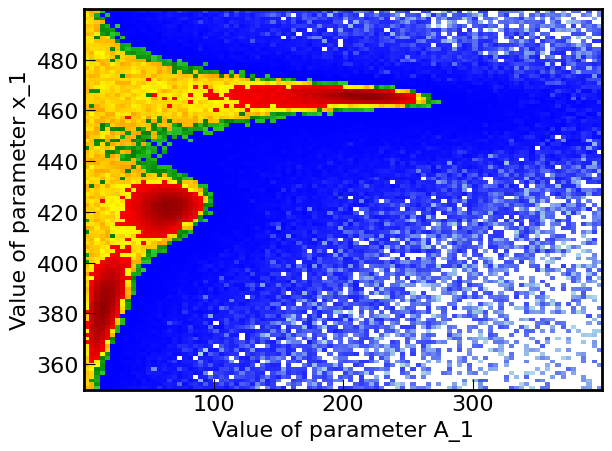

In [67]:
# Plot one parameter histogram
# Red, yellow and green region correspond to 1,2,3 sigmas
an.histo2D('A_1','x_1',bins=100,xmin=0,xmax=400,ymin=350,ymax=500)

/opt/homebrew/lib/python3.11/site-packages/anesthetic/samples.py:1403: RuntimeWarning: 38 out of 366830 samples have logL <= logL_birth,
38 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


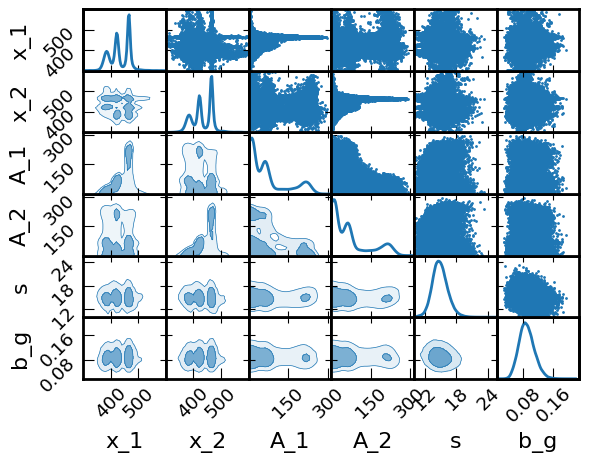

In [68]:
# Triangle plot (from anesthetic) to have a look to all parameters at the same time
an.triangle_plot(['x_1', 'x_2', 'A_1', 'A_2','s','b_g'])

### Check values

In [69]:
# Extract the raw information of evidence
print(f" Evidence: {out['evidence']['value']:.3f} ±{out['evidence']['uncertainty']:.3f}")

# Check values
is_compatible(out['evidence']['value'], evidence_ref, atol=max(evidence_ref_error, out['evidence']['uncertainty']))


 Evidence: -326.569 ±0.043


<span style='font-size:24px; color:green'>🟢 Compatible</span>

True

In [70]:
# Specific information of output parameters
par_name = 's'
print(par_name, ' = ', out['params'][par_name][ 'mean'],' ± ', out['params'][par_name][ 'std'])

# Check values
is_compatible(out['params'][par_name][ 'mean'], par1_ref, atol=max(par1_ref_error, out['params'][par_name][ 'std']))

s  =  14.932658604819844  ±  1.4696351201008324


<span style='font-size:24px; color:green'>🟢 Compatible</span>

True

### Extract computation time

In [71]:
# Miscelaneous information
out['meta']['timereal']

132.03931699998793